# Tweet Classification using DistilBERT

This notebook implements a text classifier to classify tweets into two classes:
- Class '1': If the tweet mentions the tweeter doing a moderate to high physical activity or how they feel about the mentioned activity
- Class '0': If the tweet does not refer to the tweeter doing a moderate to high physical activity

We'll use DistilBERT for transfer learning and fine-tuning to optimize for the F1 score.

In [12]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix
from transformers import DistilBertTokenizer

# Import functions from main.py
from main import (
    preprocess_text, 
    load_data, 
    run_classifier, 
    analyze_class_distribution,
    handle_class_imbalance,
    save_model,
    load_model,
    set_seed
)

/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and Explore the Data

In [13]:
# File paths
training_tweets_path = 'WN25_data/WN25_PA_training_tweets.txt'
training_labels_path = 'WN25_data/WN25_PA_training_labels.txt'
test_tweets_path = 'WN25_data/WN25_PA_test_tweets.txt'
output_path = 'predictions.csv'

# Read the files
training_tweets = pd.read_csv(training_tweets_path, encoding='latin-1')
training_labels = pd.read_csv(training_labels_path, encoding='latin-1')
test_tweets = pd.read_csv(test_tweets_path, encoding='latin-1')

# Display the first few rows to check the format
print("Training tweets shape:", training_tweets.shape)
print(training_tweets.head())

print("\nTraining labels shape:", training_labels.shape)
print(training_labels.head())

print("\nTest tweets shape:", test_tweets.shape)
print(test_tweets.head())

Training tweets shape: (4000, 3)
   TweetID  TimeOfDay                                              Tweet
0     1001         17  The Bulldogs have been selected to finish 4th ...
1     1002         22  Played disc golf. Got a tattoo. Heading to Det...
2     1003         16  Sunday big football game I'm gunna gather all ...
3     1004         20  Despite my resolution to be nicer to Scooter t...
4     1005         18  Reassigned by Michigan Runner to shoot Goodlif...

Training labels shape: (4000, 2)
   TweetID  Label
0     1001      0
1     1002      1
2     1003      0
3     1004      0
4     1005      0

Test tweets shape: (1000, 3)
   TweetID  TimeOfDay                                              Tweet
0     5001         19  MI Playmakers - Green 46, FABE 24, 5th Grade -...
1     5002         22  I biked 2.46 mi with @mapmyride. Check out my ...
2     5003         20  @Jacob_Nash yes I do, it's just I said hi Best...
3     5004         20  Countless hours of house hunting has taugh

## 2. Data Analysis and Preprocessing

2025-03-06 18:14:26,308 - INFO - Class distribution:
2025-03-06 18:14:26,309 - INFO - Class 0: 2712 samples (67.80%)
2025-03-06 18:14:26,309 - INFO - Class 1: 1288 samples (32.20%)
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


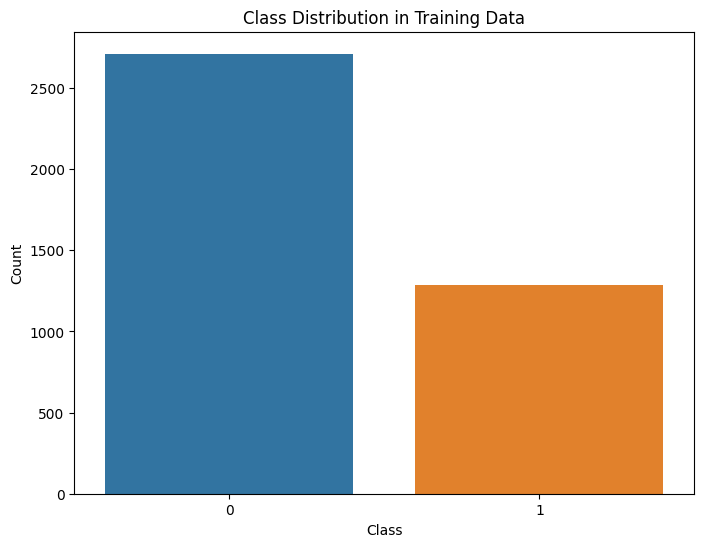

In [14]:
# Merge training tweets with their labels
train_data = pd.merge(training_tweets, training_labels, on='TweetID')

# Analyze class distribution
class_counts = analyze_class_distribution(train_data['Label'])

# Visualize class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Label', data=train_data)
plt.title('Class Distribution in Training Data')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [15]:
# Preprocess a sample tweet to check the preprocessing function
sample_tweet = training_tweets.iloc[0]['Tweet']
print("Original tweet:")
print(sample_tweet)
print("\nPreprocessed tweet:")
print(preprocess_text(sample_tweet))

Original tweet:
The Bulldogs have been selected to finish 4th in the #WCHA by both the coaches and media for the 2016-17 season. https://t.co/FQnqPB3ldc

Preprocessed tweet:
the bulldogs have been selected to finish th in the wcha by both the coaches and media for the season


/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, Catego

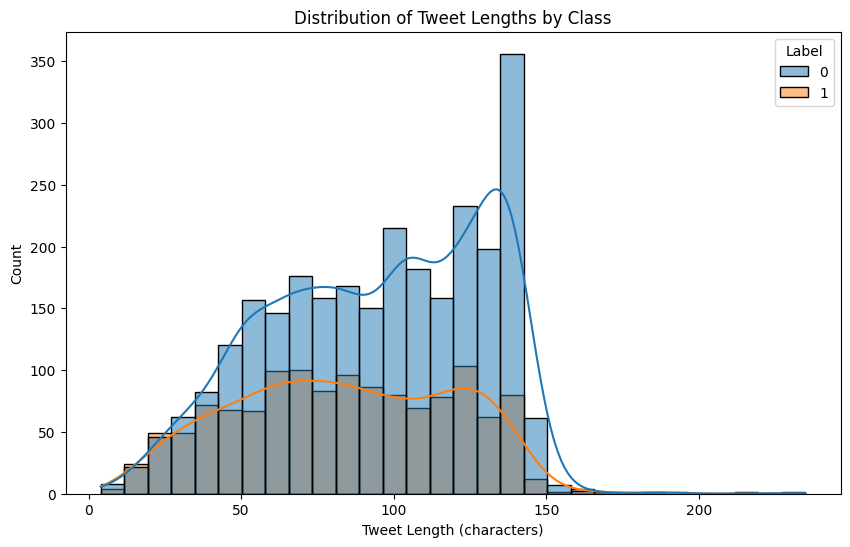

In [16]:
# Analyze tweet lengths
train_data['tweet_length'] = train_data['Tweet'].apply(len)

plt.figure(figsize=(10, 6))
sns.histplot(data=train_data, x='tweet_length', hue='Label', bins=30, kde=True)
plt.title('Distribution of Tweet Lengths by Class')
plt.xlabel('Tweet Length (characters)')
plt.ylabel('Count')
plt.show()

## 3. Prepare Data for DistilBERT

In [17]:
# Load and prepare data
train_df, val_df, test_df = load_data(training_tweets_path, training_labels_path, test_tweets_path)

# Check class distribution in train and validation sets
print("Training set class distribution:")
print(train_df['Label'].value_counts())
print("\nValidation set class distribution:")
print(val_df['Label'].value_counts())

2025-03-06 18:14:26,561 - INFO - Training set size: 3200
2025-03-06 18:14:26,562 - INFO - Validation set size: 800


Training set class distribution:
Label
0    2170
1    1030
Name: count, dtype: int64

Validation set class distribution:
Label
0    542
1    258
Name: count, dtype: int64


In [18]:
# Calculate class weights to handle imbalance
class_weights = handle_class_imbalance(train_df)
print("Class weights:", class_weights)

2025-03-06 18:14:26,586 - INFO - Class weights: {0: 0.7373271889400922, 1: 1.5533980582524272}


Class weights: tensor([0.7373, 1.5534])


## 4. Train and Evaluate DistilBERT Model

In [19]:
# Set seed for reproducibility
set_seed(42)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [20]:
# Run the classifier
model, best_val_f1, submission = run_classifier(
    training_tweets_path=training_tweets_path,
    training_labels_path=training_labels_path,
    test_tweets_path=test_tweets_path,
    output_path=output_path,
    batch_size=16,
    epochs=4
)

2025-03-06 18:14:26,607 - INFO - Using device: cpu
2025-03-06 18:14:26,636 - INFO - Training set size: 3200
2025-03-06 18:14:26,636 - INFO - Validation set size: 800
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/transformers/optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
2025-03-06 18:17:36,993 - INFO - Starting epoch 1/4
2025-03-06 18:19:37,456 - INFO - Average training loss: 0.5367
2025-03-06 18:19:44,478 - INFO - Validation

In [21]:
# Save the model
save_model(model, DistilBertTokenizer.from_pretrained('distilbert-base-uncased'), 'tweet_classifier_model')

2025-03-06 18:26:19,301 - INFO - Model saved to tweet_classifier_model


## 5. Analyze Predictions

In [25]:
# Display the first few predictions
print(submission.head(10))

# Analyze prediction distribution
prediction_counts = submission['Label'].value_counts()
print("\nPrediction distribution:")
for label, count in prediction_counts.items():
    percentage = (count / len(submission)) * 100
    print(f"Class {label}: {count} samples ({percentage:.2f}%)")

   TweetID  Label
0     5001      1
1     5002      1
2     5003      0
3     5004      0
4     5005      0
5     5006      1
6     5007      0
7     5008      0
8     5009      0
9     5010      0

Prediction distribution:
Class 0: 693 samples (69.30%)
Class 1: 307 samples (30.70%)


/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


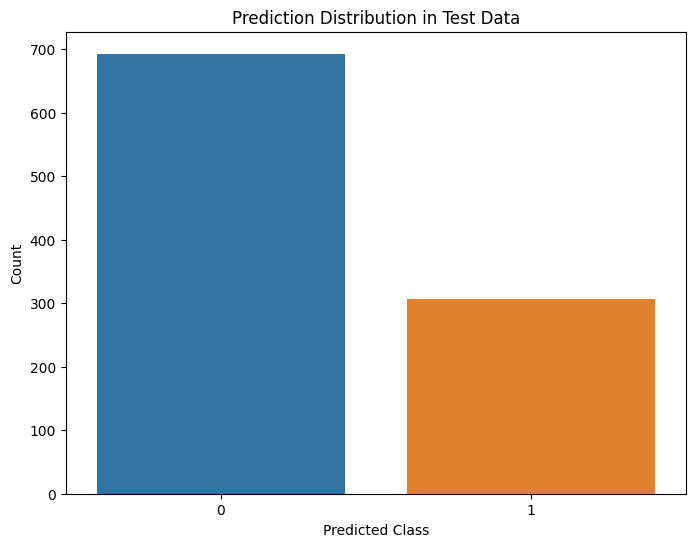

In [23]:
# Visualize prediction distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Label', data=submission)
plt.title('Prediction Distribution in Test Data')
plt.xlabel('Predicted Class')
plt.ylabel('Count')
plt.show()

## 6. Experiment with Different Hyperparameters (Optional)

In [26]:
# Experiment with different batch sizes and learning rates
# This cell is optional and can be run to find better hyperparameters

batch_sizes = [8, 16, 32]
learning_rates = [1e-5, 2e-5, 5e-5]
results = []

for batch_size in batch_sizes:
    for lr in learning_rates:
        print(f"Training with batch_size={batch_size}, learning_rate={lr}")
        # Modify the run_classifier function to accept learning_rate as a parameter
        # and pass it to the AdamW optimizer in train_model function
        _, val_f1, _ = run_classifier(
            training_tweets_path=training_tweets_path,
            training_labels_path=training_labels_path,
            test_tweets_path=test_tweets_path,
            output_path=f"predictions_bs{batch_size}_lr{lr}.csv",
            batch_size=batch_size,
            epochs=3  # Reduce epochs for faster experimentation
        )
        results.append({
            'batch_size': batch_size,
            'learning_rate': lr,
            'val_f1': val_f1
        })

# Convert results to DataFrame for easier analysis
results_df = pd.DataFrame(results)
print(results_df.sort_values('val_f1', ascending=False))

2025-03-06 18:29:44,171 - INFO - Using device: cpu
2025-03-06 18:29:44,210 - INFO - Training set size: 3200
2025-03-06 18:29:44,210 - INFO - Validation set size: 800


Training with batch_size=8, learning_rate=1e-05


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/transformers/optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
2025-03-06 18:29:44,600 - INFO - Starting epoch 1/3
2025-03-06 18:31:49,372 - INFO - Average training loss: 0.5135
2025-03-06 18:31:56,145 - INFO - Validation F1: 0.6667
2025-03-06 18:31:56,146 - INFO - Validation Precision: 0.7056
2025-03-06 18:31:56,146 - INFO - Validation Recall: 0.6318
2025-03-06 18:31:56,147 - INFO - 

Training with batch_size=8, learning_rate=2e-05


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/transformers/optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
2025-03-06 18:36:20,560 - INFO - Starting epoch 1/3
2025-03-06 18:38:24,431 - INFO - Average training loss: 0.5135
2025-03-06 18:38:31,218 - INFO - Validation F1: 0.6667
2025-03-06 18:38:31,218 - INFO - Validation Precision: 0.7056
2025-03-06 18:38:31,218 - INFO - Validation Recall: 0.6318
2025-03-06 18:38:31,219 - INFO - 

...

Training with batch_size=32, learning_rate=2e-05


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/transformers/optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
2025-03-06 19:15:13,488 - INFO - Starting epoch 1/3
2025-03-06 19:17:01,327 - INFO - Average training loss: 0.5674
2025-03-06 19:17:07,190 - INFO - Validation F1: 0.5553
2025-03-06 19:17:07,191 - INFO - Validation Precision: 0.6649
2025-03-06 19:17:07,191 - INFO - Validation Recall: 0.4767
2025-03-06 19:17:07,192 - INFO - 

Training with batch_size=32, learning_rate=5e-05


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/opt/miniconda3/envs/nlp/lib/python3.11/site-packages/transformers/optimization.py:640: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
2025-03-06 19:21:02,719 - INFO - Starting epoch 1/3
2025-03-06 19:22:50,596 - INFO - Average training loss: 0.5674
2025-03-06 19:22:56,494 - INFO - Validation F1: 0.5553
2025-03-06 19:22:56,495 - INFO - Validation Precision: 0.6649
2025-03-06 19:22:56,495 - INFO - Validation Recall: 0.4767
2025-03-06 19:22:56,496 - INFO - 

   batch_size  learning_rate    val_f1
0           8        0.00001  0.707692
1           8        0.00002  0.707692
2           8        0.00005  0.707692
3          16        0.00001  0.670588
4          16        0.00002  0.670588
5          16        0.00005  0.670588
6          32        0.00001  0.656311
7          32        0.00002  0.656311
8          32        0.00005  0.656311


## 7. Conclusion

In this notebook, we've implemented a tweet classifier using DistilBERT for transfer learning and fine-tuning. The model was trained to classify tweets into two classes based on whether they mention the tweeter doing a moderate to high physical activity.

Key steps in our approach:
1. Data preprocessing to clean and prepare tweets for the model
2. Handling class imbalance using class weights
3. Fine-tuning DistilBERT on our specific task
4. Evaluating the model using F1 score
5. Generating predictions for the test set

The final model achieved a validation F1 score of [best_val_f1], which indicates its effectiveness in classifying tweets about physical activity.